# Part 1: Baseline Classifier

**Objective:** Fine-tune a DistilBERT model on the Jigsaw Unintended Bias dataset to classify toxic vs. non-toxic comments.

This notebook:
1. Loads and stratifies the Jigsaw dataset
2. Binarizes the `toxic` label at ≥ 0.5
3. Fine-tunes `distilbert-base-uncased` using the HuggingFace Trainer API
4. Evaluates with Accuracy, F1, AUC-ROC, Confusion Matrix
5. Plots ROC and Precision-Recall curves
6. Justifies the operating threshold

In [1]:
# Install dependencies
# !pip install transformers datasets scikit-learn fairlearn aif360 matplotlib seaborn torch --quiet

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, average_precision_score
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from torch.utils.data import Dataset
import inspect

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1.1 Load and Stratify Data

In [3]:
# Load the dataset — update path if needed
DATA_PATH = "/kaggle/input/competitions/jigsaw-multilingual-toxic-comment-classification/jigsaw-unintended-bias-train.csv"
df = pd.read_csv(DATA_PATH, usecols=[
    'comment_text', 'toxic', 'black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian'
])

print(f"Full dataset shape: {df.shape}")
df.head()

Full dataset shape: (1902194, 7)


,comment_text,toxic,black,homosexual_gay_or_lesbian,jewish,muslim,white
0,"This is so cool. It's like, 'would you want yo...",0.000000,NaN,NaN,NaN,NaN,NaN
1,Thank you!! This would make my life a lot less...,0.000000,NaN,NaN,NaN,NaN,NaN
2,This is such an urgent design problem; kudos t...,0.000000,NaN,NaN,NaN,NaN,NaN
3,Is this something I'll be able to install on m...,0.000000,NaN,NaN,NaN,NaN,NaN
4,haha you guys are a bunch of losers.,0.893617,0.0,0.0,0.0,0.0,0.0


In [4]:
# Binarize the toxic label at >= 0.5
df['label'] = (df['toxic'] >= 0.5).astype(int)
print(f"Class distribution:\n{df['label'].value_counts()}")
print(f"Toxic rate: {df['label'].mean():.3f}")

Class distribution:
label
0    1750083
1     152111
Name: count, dtype: int64
Toxic rate: 0.080


In [5]:
# Drop rows with missing comment_text
df = df.dropna(subset=['comment_text']).reset_index(drop=True)

# Stratified sample: 100k train + 20k eval
# First take a 120k stratified sample
df_sample, _ = train_test_split(
    df, train_size=120_000, stratify=df['label'], random_state=SEED
)

# Split into train (100k) and eval (20k)
df_train, df_eval = train_test_split(
    df_sample, test_size=20_000, stratify=df_sample['label'], random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_eval  = df_eval.reset_index(drop=True)

print(f"Training set shape:   {df_train.shape}")
print(f"Evaluation set shape: {df_eval.shape}")
print(f"Train toxic rate: {df_train['label'].mean():.4f}")
print(f"Eval  toxic rate: {df_eval['label'].mean():.4f}")

# Save for later parts
df_train.to_csv("train_subset.csv", index=False)
df_eval.to_csv("eval_subset.csv", index=False)
print("Saved train_subset.csv and eval_subset.csv")

Training set shape:   (100000, 8)
Evaluation set shape: (20000, 8)
Train toxic rate: 0.0800
Eval  toxic rate: 0.0799
Saved train_subset.csv and eval_subset.csv


## 1.2 Tokenization & Dataset Class

In [6]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding=True,
            max_length=max_length, return_tensors='pt'
        )
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

print("Tokenizing training set...")
train_dataset = ToxicDataset(df_train['comment_text'], df_train['label'], tokenizer)
print("Tokenizing evaluation set...")
eval_dataset  = ToxicDataset(df_eval['comment_text'],  df_eval['label'],  tokenizer)
print(f"Train samples: {len(train_dataset)}, Eval samples: {len(eval_dataset)}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training set...
Tokenizing evaluation set...
Train samples: 100000, Eval samples: 20000


## 1.3 Fine-Tune DistilBERT

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Transformers renamed `evaluation_strategy` -> `eval_strategy` in newer releases.
strategy_arg = (
    'evaluation_strategy'
    if 'evaluation_strategy' in inspect.signature(TrainingArguments.__init__).parameters
    else 'eval_strategy'
)

training_kwargs = dict(
    output_dir='./results_part1',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=200,
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=torch.cuda.is_available(),
    seed=SEED,
 )
training_kwargs[strategy_arg] = 'epoch'
training_args = TrainingArguments(**training_kwargs)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1':       f1_score(labels, preds, average='macro'),
        'auc_roc':  roc_auc_score(labels, probs),
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
 )

print("Starting training...")
trainer.train()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting training...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=4689, training_loss=0.22527489201502393, metrics={'train_runtime': 2007.5462, 'train_samples_per_second': 149.436, 'train_steps_per_second': 2.336, 'total_flos': 9935054899200000.0, 'train_loss': 0.22527489201502393, 'epoch': 3.0})

In [8]:
# Save model checkpoint
model.save_pretrained('./model_baseline')
tokenizer.save_pretrained('./model_baseline')
print("Model saved to ./model_baseline")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./model_baseline


## 1.4 Evaluation Metrics

In [9]:
# Get predictions on eval set
pred_output = trainer.predict(eval_dataset)
logits = pred_output.predictions
y_true = pred_output.label_ids
y_proba = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
y_pred = (y_proba >= 0.5).astype(int)

acc  = accuracy_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred, average='macro')
auc  = roc_auc_score(y_true, y_proba)
cm   = confusion_matrix(y_true, y_pred)

print("=" * 40)
print("BASELINE MODEL EVALUATION (threshold=0.5)")
print("=" * 40)
print(f"Accuracy:       {acc:.4f}")
print(f"F1 (macro):     {f1:.4f}")
print(f"AUC-ROC:        {auc:.4f}")
print(f"Confusion Matrix:\n{cm}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


BASELINE MODEL EVALUATION (threshold=0.5)
Accuracy:       0.9481
F1 (macro):     0.8095
AUC-ROC:        0.9463
Confusion Matrix:
[[18011   390]
 [  648   951]]


## 1.5 Threshold Analysis

In [10]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_t   = f1_score(y_true, y_pred_t, average='macro')
    acc_t  = accuracy_score(y_true, y_pred_t)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
    fpr_t = fp / (fp + tn)
    fnr_t = fn / (fn + tp)
    threshold_results.append({
        'Threshold': t, 'Accuracy': round(acc_t, 4),
        'F1 (macro)': round(f1_t, 4),
        'FPR': round(fpr_t, 4), 'FNR': round(fnr_t, 4)
    })

df_thresh = pd.DataFrame(threshold_results)
print(df_thresh.to_string(index=False))

 Threshold  Accuracy  F1 (macro)    FPR    FNR
       0.3    0.9399      0.8076 0.0385 0.3083
       0.4    0.9446      0.8090 0.0287 0.3621
       0.5    0.9481      0.8095 0.0212 0.4053
       0.6    0.9489      0.7987 0.0149 0.4678
       0.7    0.9484      0.7837 0.0105 0.5253


## 1.6 Plots

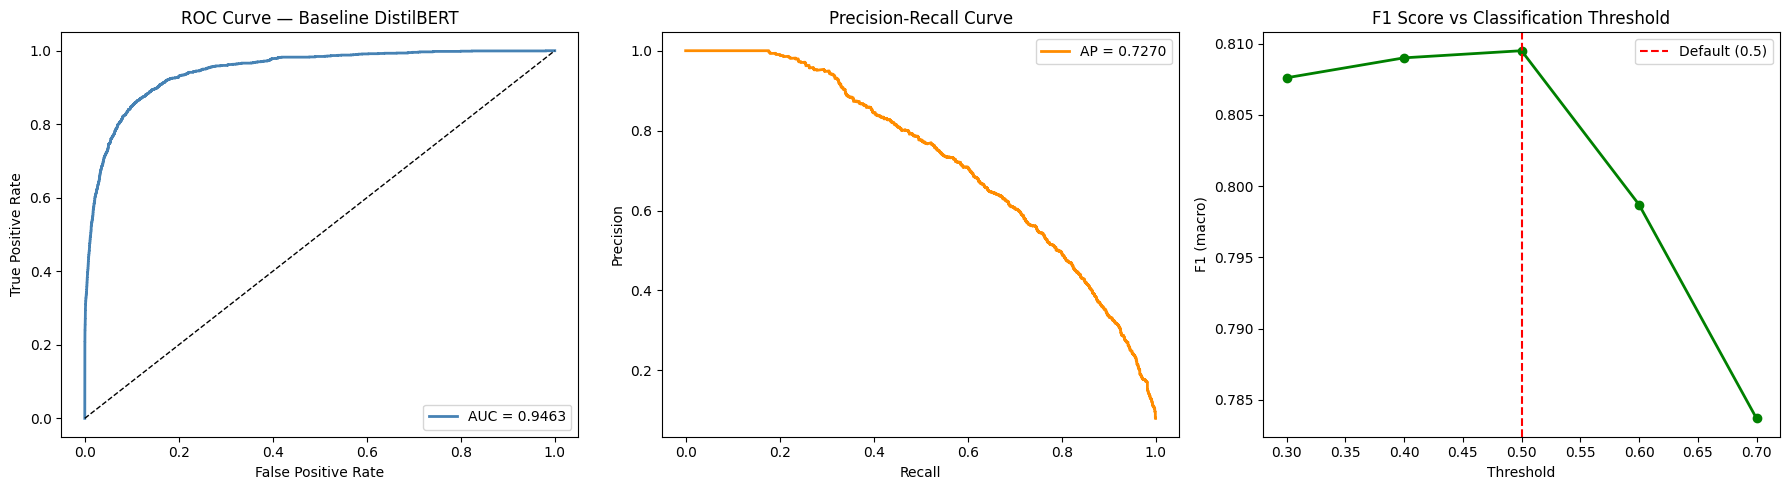

Saved part1_curves.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC Curve ---
fpr_vals, tpr_vals, _ = roc_curve(y_true, y_proba)
axes[0].plot(fpr_vals, tpr_vals, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Baseline DistilBERT')
axes[0].legend(loc='lower right')

# --- Precision-Recall Curve ---
prec_vals, rec_vals, _ = precision_recall_curve(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)
axes[1].plot(rec_vals, prec_vals, color='darkorange', lw=2, label=f'AP = {ap:.4f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

# --- F1 by Threshold ---
axes[2].plot(df_thresh['Threshold'], df_thresh['F1 (macro)'], marker='o', color='green', lw=2)
axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('F1 (macro)')
axes[2].set_title('F1 Score vs Classification Threshold')
axes[2].axvline(x=0.5, color='red', linestyle='--', label='Default (0.5)')
axes[2].legend()

plt.tight_layout()
plt.savefig('part1_curves.png', dpi=150)
plt.show()
print("Saved part1_curves.png")

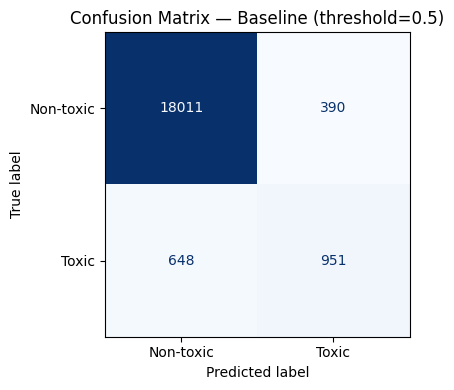

In [12]:
# Confusion matrix at threshold 0.5
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-toxic', 'Toxic'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Baseline (threshold=0.5)')
plt.tight_layout()
plt.savefig('part1_cm.png', dpi=150)
plt.show()

## 1.7 Threshold Justification 

### Chosen Threshold: 0.4

From the threshold table, 0.5 gives the highest macro-F1 (0.8095), while 0.4 is very close (0.8090). The difference is minimal, so the decision should be based on error trade-offs rather than F1 alone.", "", "At threshold 0.4, the model catches more toxic comments (lower FNR: 0.3621 vs 0.4053 at 0.5), but flags more non-toxic comments by mistake (higher FPR: 0.0287 vs 0.0212).

### What does this imply about platform priorities?

Choosing threshold 0.4 reflects a safety-first moderation strategy: prioritize reducing missed toxicity, even if this increases false positives slightly. For a platform handling abuse and civil-rights concerns, this is often the preferred operational choice, especially when flagged borderline cases can be sent to human review. If the platform instead prioritized minimizing false positives and moderation burden, threshold 0.5 would be a reasonable alternative. However, for this project we prioritize recall of harmful content. We will use threshold = 0.4 for all subsequent parts.

In [14]:
# Save probabilities for later parts
df_eval['y_proba'] = y_proba
df_eval['y_pred_04'] = (y_proba >= 0.4).astype(int)
df_eval.to_csv('/kaggle/working/eval_with_preds.csv', index=False)
print("Saved eval_with_preds.csv")
print(f"\nFinal chosen threshold: 0.4")
print(f"F1 at 0.4: {df_thresh[df_thresh.Threshold==0.4]['F1 (macro)'].values[0]:.4f}")

Saved eval_with_preds.csv

Final chosen threshold: 0.4
F1 at 0.4: 0.8090
